In [53]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

In [54]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statistics import mode
import folium
from folium.plugins import MarkerCluster
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import random
from sklearn.impute import SimpleImputer
from typing import Dict
import seaborn as sns
from sklearn.impute import SimpleImputer
from IPython.display import display, HTML
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

In [55]:
from typing import List, Tuple
from Algorithms.CDREC import CDRec
from Algorithms.TKCM import TKCM
from Algorithms.TKCM_Weighted import TKCM_Weighted
from Algorithms.DynaMMO import DynaMMo
from Algorithms.SoftImpute import SoftImpute
from Algorithms.SVDImpute import IterativeSVD
from Algorithms.trmf import TRMFImputer
from Algorithms.ST_MVL import ST_MVL
from Algorithms.TKCM_PLUS import TKCM_PLUS
from Algorithms.TKCM_PRO import TKCM_PRO


In [56]:

# # Load dataset
valley_df = pd.read_csv("D:\\Thesis\\Project\\Data\\valley_data.csv")

# Count different types of missingness
stats = {
    "Total Rows": len(valley_df),
    "Total Columns": len(valley_df.columns),
    "Zero Values": (valley_df == 0).sum().sum(),
    "NaN Values": valley_df.isna().sum().sum(),
    "Blank Strings": (valley_df == "").sum().sum(),
    "Unknown Strings": (valley_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,7079427
1,Total Columns,6
2,Zero Values,1667902
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


In [57]:
valley_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,37100MS,LT,Temperatura dell´aria,°C,2025-01-01 00:00:00,-10.4
1,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 23:30:00,-8.9
2,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 23:00:00,-9.5
3,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 22:30:00,-8.1
4,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 22:00:00,-8.8


In [58]:
valley_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079427 entries, 0 to 7079426
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 324.1+ MB


In [59]:
valley_df.describe()

,value
count,7.079427e+06
mean,1.722966e+02
std,3.336668e+02
min,-9.760000e+01
25%,0.000000e+00
50%,3.600000e+00
75%,1.000000e+02
max,1.474800e+03


In [60]:
# Preview data
print("🔍 Shape:", valley_df.shape)

🔍 Shape: (7079427, 6)


In [61]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", valley_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


In [62]:
unique_values = valley_df['sensor_code'].unique()
unique_values

array(['LT', 'N', 'WR', 'WG', 'WG.BOE', 'LF', 'LD.RED', 'GS', 'SD', 'HS',
       'W', 'WT'], dtype=object)

In [63]:
unique_values1 = valley_df['station_code'].unique()
unique_values1

array(['37100MS', '20500MS', '19300MS', '80300MS', '50500MS', '34500MS',
       '56900MS', '54500MS', '69900MS', '09700MS', '82200MS', '88820MS',
       '59700MS', '85120MS', '83200MS', '86900MS', '39100MS', '08200MS',
       '23200MS', '47400MS', '86600MS', '37700MS', '74900MS', '89190MS',
       '22210MS', '25900MS', '73500MS', '68600MS', '02200MS', '03100MS',
       '41000MS', '75600MS', '62600MS', '74200MS', '11400MS', '02500MS',
       '33500MS', '44500MS', '06400MS', '65600MS', '24400MS', '43200MS',
       '78305MS', '56500MS', '42700MS', '15800MS', '65350MS', '89950SE',
       '02250SE', '78150SE', '82910MS', '47150SE', '27100MS', '89155SE',
       '89355SE', '85700MS', '89055SE', '42150SE', '39050SE', '79450SE',
       '87300MS', '66500MS', '20910MS', '31410MS', '78110MS', '61300MS',
       '01110MS', '71510MS', '79300MS', '75510SE', '90150SE', '91510MS'],
      dtype=object)

In [64]:
unique_values2 = valley_df['description_it'].unique()
unique_values2

array(['Temperatura dell´aria', 'Precipitazioni', 'Direzione del vento',
       'Velocità del vento', 'Velocitá raffica', 'Umidità relativa',
       'Pressione atmosferica', 'Radiazione globale ',
       'Durata soleggiamento', 'Altezza neve al suolo',
       'Livello idrometrico', 'Temperatura acqua'], dtype=object)

In [65]:
unique_values3 = valley_df['unit'].unique()
unique_values3

array(['°C', 'mm', '° ', 'm/s', '%', 'hPa', 'W/m²', 's', 'cm'],
      dtype=object)

In [66]:
unique_values4 = valley_df['value'].unique()
unique_values4

array([-10.4,  -8.9,  -9.5, ..., 981.9, 855.3, 802.7], shape=(11245,))

In [67]:
column_names = list(valley_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

In [68]:
zero_counts = (valley_df == 0).sum()
print(zero_counts)

station_code            0
sensor_code             0
description_it          0
unit                    0
timestamp               0
value             1667902
dtype: int64


In [69]:
valley_df[valley_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
116,37100MS,LT,Temperatura dell´aria,°C,2024-12-29 14:00:00,0.0
338,37100MS,LT,Temperatura dell´aria,°C,2024-12-24 23:00:00,0.0
426,37100MS,LT,Temperatura dell´aria,°C,2024-12-23 03:00:00,0.0
598,37100MS,LT,Temperatura dell´aria,°C,2024-12-19 13:00:00,0.0
637,37100MS,LT,Temperatura dell´aria,°C,2024-12-18 17:30:00,0.0


In [70]:
# Make sure 'value' is numeric
valley_df['value'] = pd.to_numeric(valley_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    valley_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


   sensor_code  total_entries  zero_count  zero_percentage
0            N         585918      565938        96.589967
1           SD         773271      643102        83.166445
2           GS         758400      438331        57.796809
3            W          83263        5222         6.271693
4           LT         889920        7619         0.856144
5           WG         713371        4772         0.668937
6           HS          29182         170         0.582551
7       WG.BOE         713371        2423         0.339655
8           WT          83262          60         0.072062
9           WR         713371         265         0.037148
10          LF         875328           0         0.000000
11      LD.RED         860770           0         0.000000


In [71]:
# Step 1: Select sensor `LF`
lf_df = valley_df[valley_df['sensor_code'] == 'LF'].copy()

In [72]:
# Step 2: Replace `0.0` values with NaN
lf_df.loc[lf_df['value'] == 0.0, 'value'] = np.nan

In [73]:
# Step 3: Pivot to wide format (timestamp × station_code)
lf_df['timestamp'] = pd.to_datetime(lf_df['timestamp'])
pivot_df = lf_df.pivot(index='timestamp', columns='station_code', values='value')

In [74]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [75]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

In [76]:
clean_df

station_code,01110MS,02200MS,02500MS,03100MS,06400MS,08200MS,09700MS,11400MS,15800MS,19300MS,...,82910MS,83200MS,85120MS,85700MS,86600MS,86900MS,87300MS,88820MS,89190MS,91510MS
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,99.1,90.4,82.5,86.2,94.8,99.8,92.7,91.6,91.9,90.6,...,93.8,87.7,99.9,96.8,95.8,98.1,97.6,83.5,84.3,99.9
2023-01-01 00:30:00,98.1,90.8,80.8,84.9,97.1,99.8,91.1,92.1,92.7,91.7,...,91.8,87.0,99.9,97.7,94.5,97.0,97.5,82.7,84.3,99.9
2023-01-01 01:00:00,98.0,91.5,81.9,83.5,96.7,99.8,90.0,89.1,92.4,90.1,...,92.1,85.3,99.9,97.1,93.5,98.5,99.7,89.8,81.3,99.9
2023-01-01 01:30:00,99.7,92.6,81.1,85.3,97.7,99.8,89.4,88.5,93.3,89.2,...,95.1,84.2,99.9,98.8,92.5,99.2,96.4,90.6,83.9,99.9
2023-01-01 02:00:00,99.8,94.2,81.9,84.5,95.4,99.8,88.2,86.2,94.2,89.1,...,98.6,88.4,99.9,99.6,94.5,99.0,99.9,90.0,80.9,99.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,54.5,74.4,38.3,53.7,48.4,91.3,64.9,51.1,49.7,89.4,...,84.0,90.2,47.1,100.2,99.6,98.7,53.8,95.8,64.1,96.9
2024-12-31 22:30:00,54.7,75.9,41.8,56.0,46.0,91.3,67.3,51.9,50.2,90.5,...,84.5,88.9,48.7,100.2,99.1,100.0,54.0,99.0,61.4,96.0
2024-12-31 23:00:00,54.7,77.3,39.0,55.8,46.4,92.2,64.2,51.1,51.0,90.4,...,85.7,89.0,48.4,99.7,99.7,100.0,57.7,96.6,63.5,96.1


In [77]:
# Step 6: Pick a target station (first available column)
target_station = clean_df.columns[2]

In [78]:
target_station

'02500MS'

In [79]:
# Step 7: Compute Pearson correlations with all other stations
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

In [80]:
correlations

station_code
15800MS    0.860133
03100MS    0.856343
06400MS    0.820458
20910MS    0.815276
24400MS    0.812125
71510MS    0.806599
68600MS    0.800845
01110MS    0.791615
20500MS    0.790726
11400MS    0.787193
65600MS    0.757288
02200MS    0.756943
87300MS    0.755742
85120MS    0.755661
78110MS    0.751061
79300MS    0.736962
34500MS    0.730753
75600MS    0.725095
74200MS    0.723658
73500MS    0.720382
66500MS    0.720341
25900MS    0.701794
89190MS    0.688170
82200MS    0.681692
44500MS    0.661228
47400MS    0.660803
78305MS    0.656539
82910MS    0.645984
69900MS    0.640392
50500MS    0.635309
09700MS    0.633138
54500MS    0.627258
61300MS    0.615036
80300MS    0.614604
37700MS    0.610875
08200MS    0.609098
22210MS    0.560592
31410MS    0.544317
42700MS    0.535828
37100MS    0.530221
83200MS    0.519141
62600MS    0.510519
74900MS    0.487708
19300MS    0.482003
23200MS    0.477953
39100MS    0.473874
88820MS    0.465987
86900MS    0.454714
41000MS    0.453751
56500MS

In [81]:
# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [82]:
top_refs

['15800MS', '03100MS']

In [83]:
final_df

station_code,02500MS,15800MS,03100MS
timestamp,,,
2023-01-01 00:00:00,82.5,91.9,86.2
2023-01-01 00:30:00,80.8,92.7,84.9
2023-01-01 01:00:00,81.9,92.4,83.5
2023-01-01 01:30:00,81.1,93.3,85.3
2023-01-01 02:00:00,81.9,94.2,84.5
...,...,...,...
2024-12-31 22:00:00,38.3,49.7,53.7
2024-12-31 22:30:00,41.8,50.2,56.0
2024-12-31 23:00:00,39.0,51.0,55.8


In [84]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [85]:
pattern_df

station_code,02500MS,15800MS,03100MS,06400MS
timestamp,,,,
2023-01-01 00:00:00,82.5,91.9,86.2,94.8
2023-01-01 00:30:00,80.8,92.7,84.9,97.1
2023-01-01 01:00:00,81.9,92.4,83.5,96.7
2023-01-01 01:30:00,81.1,93.3,85.3,97.7
2023-01-01 02:00:00,81.9,94.2,84.5,95.4
...,...,...,...,...
2024-12-31 22:00:00,38.3,49.7,53.7,48.4
2024-12-31 22:30:00,41.8,50.2,56.0,46.0
2024-12-31 23:00:00,39.0,51.0,55.8,46.4


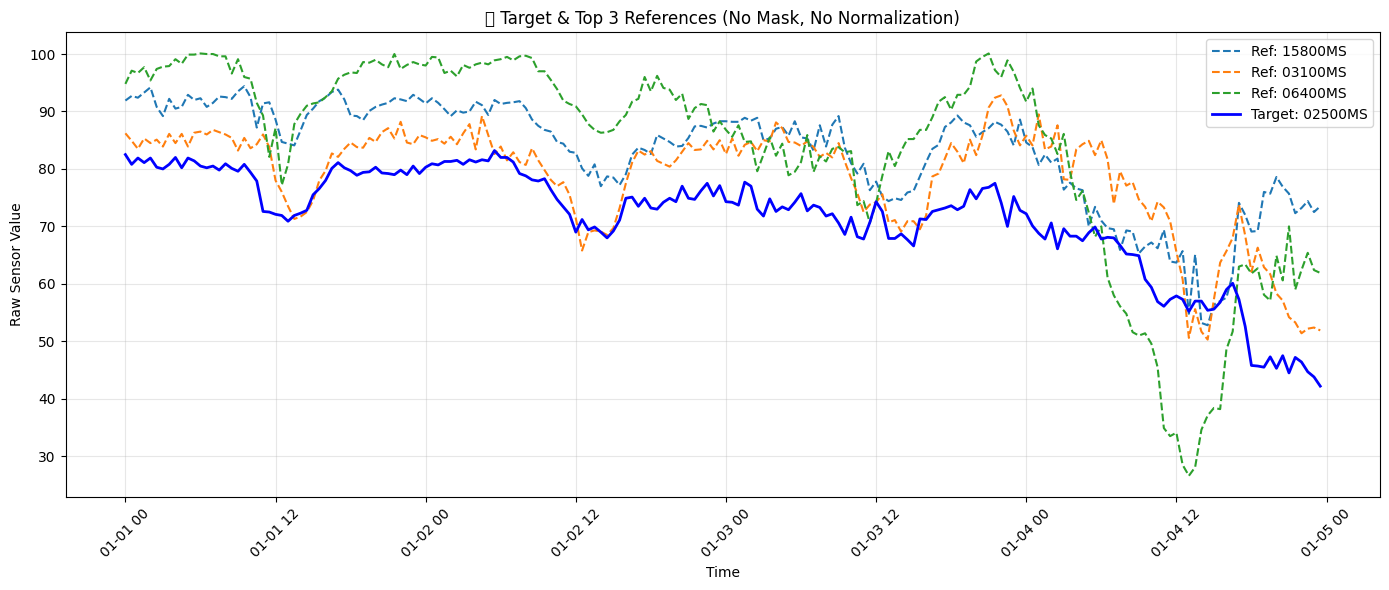

In [86]:
# Define the stations exactly as in your DataFrame
target = "02500MS"
references = ["15800MS","03100MS","06400MS"]

# Define time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slice the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plot reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plot target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [87]:
# -------------------------------------------
# 🔹 STEP 1: Normalize the Time Series Data
# -------------------------------------------

from sklearn.preprocessing import StandardScaler

# 1️⃣ Initialize the Scaler
scaler = StandardScaler()

# 2️⃣ Fit the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

# 3️⃣ Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

# 4️⃣ Print shape and preview
print("✅ Normalized shape:", normalized_df.shape)
display(normalized_df.head())


✅ Normalized shape: (14593, 4)


station_code,02500MS,15800MS,03100MS,06400MS
timestamp,,,,
2023-01-01 00:00:00,1.119923,1.189939,0.666856,1.250501
2023-01-01 00:30:00,1.038581,1.225965,0.609234,1.356561
2023-01-01 01:00:00,1.091214,1.212455,0.547179,1.338115
2023-01-01 01:30:00,1.052935,1.252984,0.626964,1.384229
2023-01-01 02:00:00,1.091214,1.293513,0.591504,1.278168


In [88]:
# ---------------------------------------------------------
# 🔹 STEP 2: Define function to inject single-missing in the middle
# ---------------------------------------------------------

def introduce_single_missing_middle(series: pd.Series) -> Tuple[pd.Series, int, float]:
    """
    Introduce a single NaN value in the middle of a time series.

    Parameters:
        series (pd.Series): The original time series

    Returns:
        masked_series (pd.Series): The modified series with one NaN
        missing_index (int): Index where the value was masked
        true_value (float): The original value that was replaced with NaN
    """
    ts = series.copy()
    mid_index = len(ts) // 2
    true_value = ts.iloc[mid_index]
    ts.iloc[mid_index] = np.nan
    return ts, mid_index, true_value


In [89]:
# ---------------------------------------------------------
# 🔹 STEP 2b: Apply block-missing to the normalized target series
# ---------------------------------------------------------

# Define target station (from your pattern_df)
target_station = "02500MS"

# Apply the masking function for a single missing value in the middle
masked_target, start_idx, true_val = introduce_single_missing_middle(
    normalized_df[target_station]
)

# ✅ Optional: Print info about the missing point
print(f"🎯 Single missing value injected at index {start_idx}")
print(f"📉 True value at that point: {true_val:.4f}")
print("🕓 Timestamp of missing value:", normalized_df.index[start_idx])


🎯 Single missing value injected at index 7296
📉 True value at that point: -0.6840
🕓 Timestamp of missing value: 2024-01-05 00:00:00


In [90]:
# ---------------------------------------------------------
# 🔹 STEP 3: Prepare NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

# 1️⃣ Extract the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

# 2️⃣ Get reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

# 3️⃣ Get the masked target series as array (shape: time,)
masked_target_array = masked_target.to_numpy().copy()

# 4️⃣ Get the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()


# ✅ Preview shapes and sanity check
print("🎯 Target shape:", masked_target_array.shape)
print("📘 Ref matrix shape:", ref_matrix.shape)


🎯 Target shape: (14593,)
📘 Ref matrix shape: (3, 14593)


In [91]:
# -----------------------------------------------
# 🔹 STEP 4.1: Set safe parameters for all models
# -----------------------------------------------

k = 5  # number of top matching sequences (for TKCMs)
l = 4  # sliding window size
rank = max(1, min(ref_matrix.shape[0] - 1, 2))  # safe low-rank dimension for SVD, TRMF


In [92]:
from sklearn.impute import SimpleImputer

# --- Basic Imputers ---

class ZeroImputer:
    def fit_transform(self, X):
        X = X.copy()
        X[np.isnan(X)] = 0
        return X


class MinImputer:
    def fit_transform(self, X):
        fill_value = np.nanmin(X[~np.isnan(X)])
        imp = SimpleImputer(strategy='constant', fill_value=fill_value)
        return imp.fit_transform(X)

class InterpolationImputer:
    def fit_transform(self, X):
        return pd.DataFrame(X).interpolate(method='linear', axis=0, limit_direction='both').values


In [93]:
# -----------------------------------------------
# 🔹 STEP 4.2: Apply each model with correct usage
# -----------------------------------------------

# Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])

# 1️⃣ TKCM
tkcm = TKCM(k=k, l=l)
tkcm_imputed = tkcm.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

# 2️⃣ TKCM_PLUS
tkcm_plus = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5)
tkcm_plus_imputed = tkcm_plus.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

# 3️⃣ TKCM_Weighted
tkcm_w = TKCM_Weighted(k=k, l=l)
tkcm_weighted_imputed = tkcm_w.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

# 4️⃣ TKCM_PRO
tkcm_pro = TKCM_PRO(k=k, l=l)
tkcm_pro_imputed = tkcm_pro.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)


# 4️⃣ CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Only return target row

# 5️⃣ DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

# 6️⃣ SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

# 7️⃣ IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

# 8️⃣ ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

# 9️⃣ TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]

# 🔟 Zero Imputer
zero_imputer = ZeroImputer()
zero_imputed = zero_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣1️⃣ Min Imputer
min_imputer = MinImputer()
min_imputed = min_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣2️⃣ Interpolation Imputer
interp_imputer = InterpolationImputer()
interp_imputed = interp_imputer.fit_transform(X_stacked.copy())[0]


In [94]:
results_point = []

# 🎯 True value and index of the missing point
true_val = true_target_array[start_idx]
idx = start_idx  # single missing index

# ✅ Helper to evaluate each method
def evaluate_single(name, imputed_array):
    try:
        predicted_val = imputed_array[idx]
        if np.isnan(predicted_val):
            raise ValueError("NaN predicted")
        
        # Core errors
        mae = abs(predicted_val - true_val)
        rmse = np.sqrt((predicted_val - true_val) ** 2)
        me = predicted_val - true_val  # Mean Error (single value)
        
        # Bias-variance (trivial for single point)
        bias_sq = (predicted_val - true_val) ** 2
        variance = 0.0

        results_point.append({
            "Method": name,
            "Missing Point": "Middle",
            "Imputed Value": round(predicted_val, 4),
            "True Value": round(true_val, 4),
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "ME": round(me, 4),
            "Bias^2": round(bias_sq, 4),
            "Variance": round(variance, 4)
        })
    except Exception as e:
        print(f"❌ {name} failed: {e}")
        results_point.append({
            "Method": name,
            "Missing Point": "Middle",
            "Imputed Value": "NaN",
            "True Value": round(true_val, 4),
            "MAE": "NaN",
            "RMSE": "NaN",
            "ME": "NaN",
            "Bias^2": "NaN",
            "Variance": "NaN"
        })


In [95]:
# Step 1: Stack masked target + reference
# Before calling .impute(), set all NaNs in references to 0
X_stmv = np.vstack([masked_target_array, ref_matrix])
X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])  # Remove NaNs in references

# Step 2: Run
try:
    st_mvl_model = ST_MVL()
    st_mvl_imputed = st_mvl_model.impute(X_stmv)[0]
    evaluate_single("ST_MVL", st_mvl_imputed)
except Exception as e:
    print("❌ ST_MVL failed:", e)
    evaluate_single("ST_MVL", np.full_like(masked_target_array, np.nan))


In [96]:
# Step 1: Prep TRMF input (shape = time x features)
X_trmf_input = np.vstack([masked_target_array, ref_matrix]).T.copy()
observed_mask = ~np.isnan(X_trmf_input)
X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)

# Step 2: Fit & transform
try:
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()
    trmf_imputed = X_trmf_output[:, 0]  # First column is the target
    evaluate_single("TRMF", trmf_imputed)
except Exception as e:
    print("❌ TRMF failed:", e)
    evaluate_single("TRMF", np.full_like(masked_target_array, np.nan))


In [101]:
results_point = []

# 🎯 True value and index of the missing point
true_val = true_target_array[start_idx]
idx = start_idx  # single missing index

# ✅ Helper to evaluate each method
def evaluate_single(name, imputed_array):
    try:
        predicted_val = imputed_array[idx]
        if np.isnan(predicted_val):
            raise ValueError("NaN predicted")
        mae = abs(predicted_val - true_val)
        rmse = np.sqrt((predicted_val - true_val) ** 2)
        results_point.append({
            "Method": name,
            "Missing Point": "Middle",
            "Imputed Value": round(predicted_val, 4),
            "True Value": round(true_val, 4),
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })
    except Exception as e:
        print(f"❌ {name} failed: {e}")
        results_point.append({
            "Method": name,
            "Missing Point": "Middle",
            "Imputed Value": "NaN",
            "True Value": round(true_val, 4),
            "MAE": "NaN",
            "RMSE": "NaN"
        })



# ✅ TKCM Variants
for method_name, model in {
    "TKCM": TKCM(k=k, l=l),
    "TKCM_PLUS": TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5),
    "TKCM_Weighted": TKCM_Weighted(k=k, l=l),
    "TKCM_PRO": TKCM_PRO(k=k, l=l),
}.items():
    try:
        imputed = model.impute(masked_target_array.copy(), offset=idx, ref_ts=ref_matrix)
        evaluate_single(method_name, imputed)
    except Exception as e:
        print(f"❌ {method_name} failed (wrapper): {e}")
        evaluate_single(method_name, np.full_like(masked_target_array, np.nan))

# ✅ Baseline Models (already computed)
baseline_models = {
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
}

evaluate_single("ST_MVL", st_mvl_imputed)
evaluate_single("TRMF", trmf_imputed)


for name, imputed_array in baseline_models.items():
    evaluate_single(name, imputed_array)

# ✅ Final Results Table
results_df = pd.DataFrame(results_point)
display(results_df.style.background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"]))


,Method,Missing Point,Imputed Value,True Value,MAE,RMSE
0,TKCM,Middle,-0.816000,-0.684000,0.132100,0.132100
1,TKCM_PLUS,Middle,-0.331800,-0.684000,0.352200,0.352200
2,TKCM_Weighted,Middle,-0.814200,-0.684000,0.130200,0.130200
3,TKCM_PRO,Middle,-1.266800,-0.684000,0.582900,0.582900
4,ST_MVL,Middle,-0.529500,-0.684000,0.154500,0.154500
5,TRMF,Middle,-0.150300,-0.684000,0.533700,0.533700
6,CDRec,Middle,-0.304400,-0.684000,0.379600,0.379600
7,DynaMMo,Middle,-0.306400,-0.684000,0.377500,0.377500
8,SoftImpute,Middle,-0.302400,-0.684000,0.381600,0.381600
9,SVDImpute,Middle,-0.306300,-0.684000,0.377700,0.377700


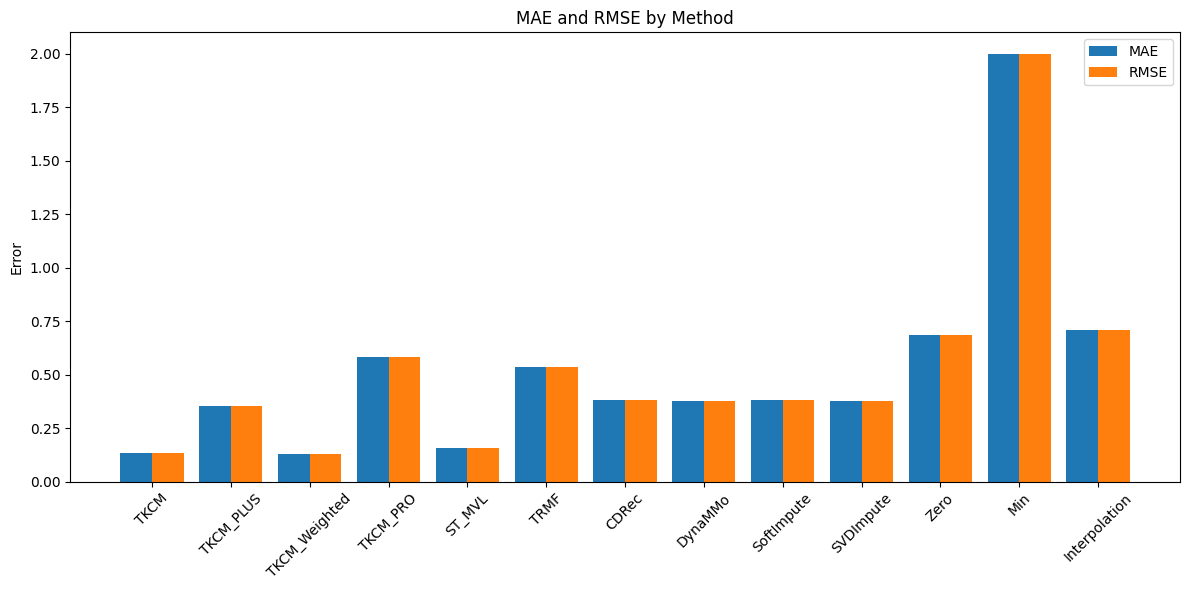

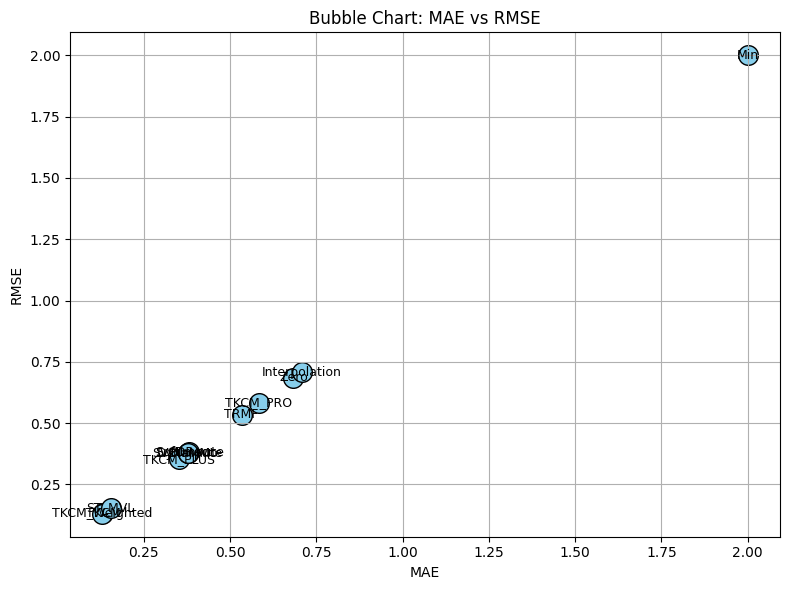

In [98]:
# Convert results_point to DataFrame for plotting
results_df = pd.DataFrame(results_point)

# Filter out methods with valid numeric values
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = plot_df["MAE"].astype(float)
plot_df["RMSE"] = plot_df["RMSE"].astype(float)

# ------------------------
# 📊 Bar Plot: MAE & RMSE
# ------------------------
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.4
x = range(len(plot_df))

ax.bar([i - bar_width/2 for i in x], plot_df["MAE"], width=bar_width, label="MAE")
ax.bar([i + bar_width/2 for i in x], plot_df["RMSE"], width=bar_width, label="RMSE")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Method"], rotation=45)
ax.set_ylabel("Error")
ax.set_title("MAE and RMSE by Method")
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 🔵 Bubble Plot: MAE vs RMSE
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(plot_df["MAE"], plot_df["RMSE"],
                     s=200, c='skyblue', edgecolors='black')

# Annotate each point
for i, row in plot_df.iterrows():
    ax.annotate(row["Method"], (row["MAE"], row["RMSE"]), fontsize=9,
                ha='center', va='center')

ax.set_xlabel("MAE")
ax.set_ylabel("RMSE")
ax.set_title("Bubble Chart: MAE vs RMSE")
plt.grid(True)
plt.tight_layout()
plt.show()


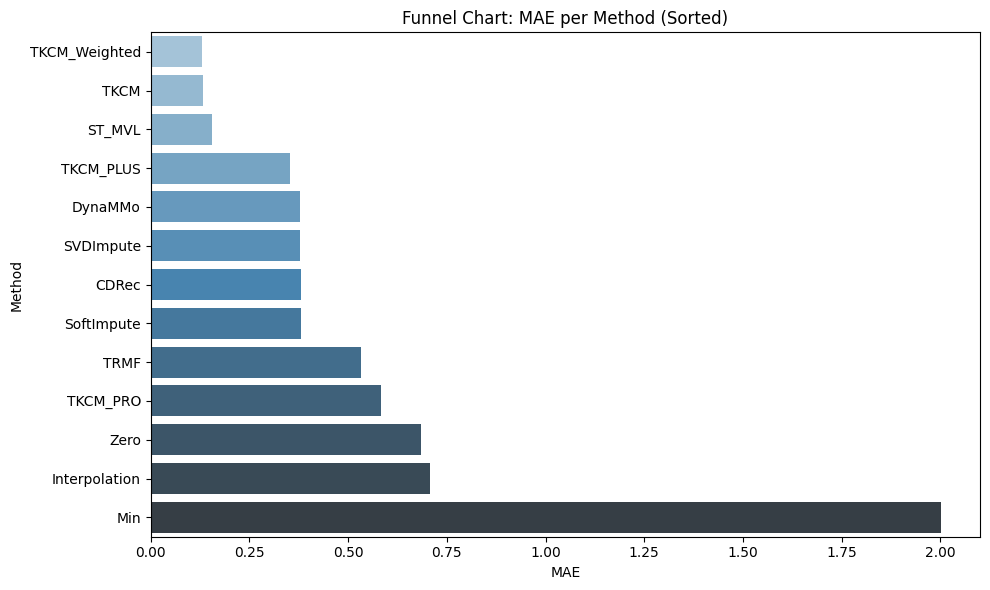

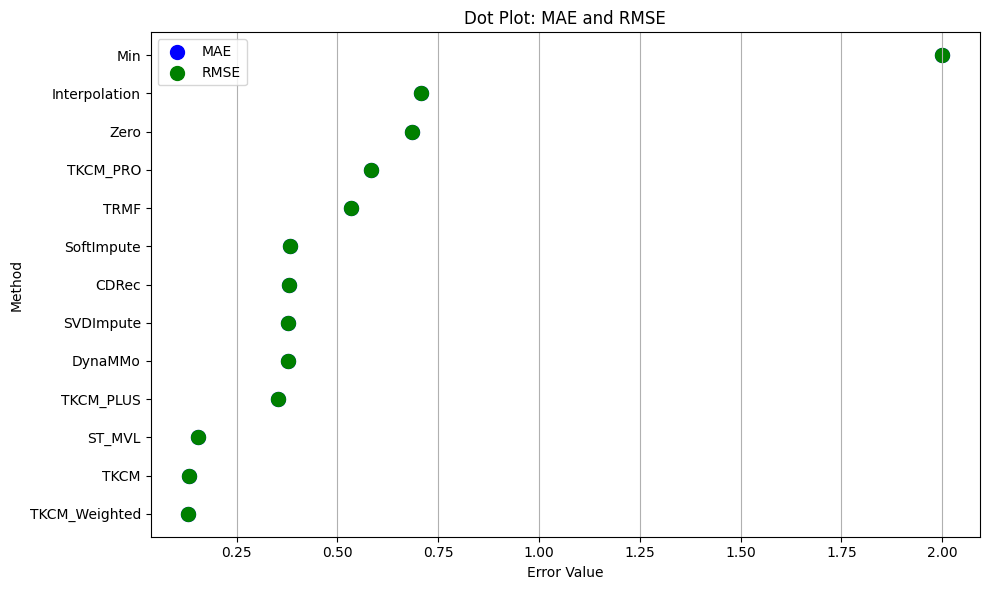

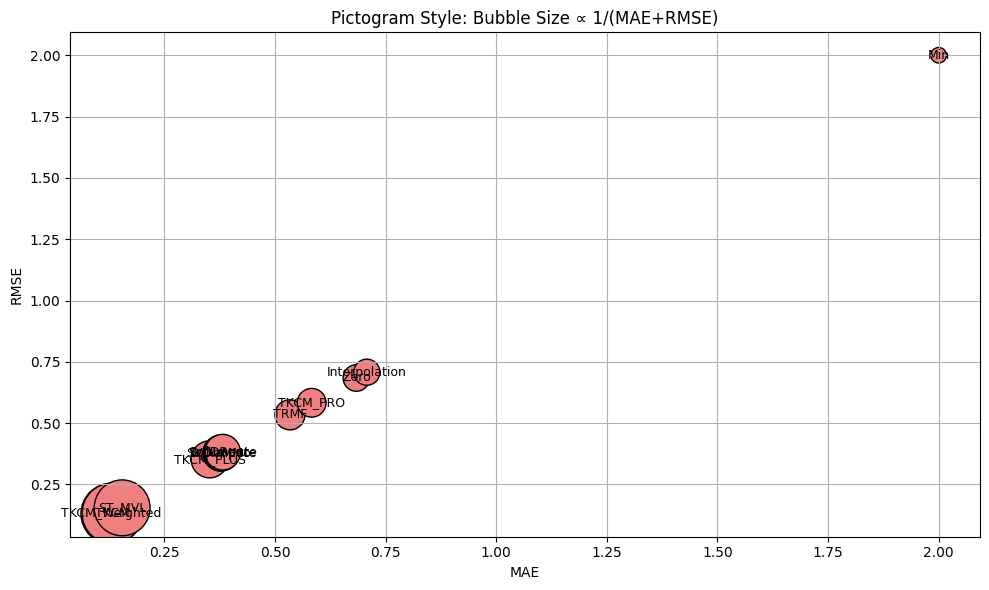

In [99]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Use existing plot_df from previous context
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = plot_df["MAE"].astype(float)
plot_df["RMSE"] = plot_df["RMSE"].astype(float)

# Sort by MAE for consistent plotting
plot_df = plot_df.sort_values("MAE").reset_index(drop=True)

# --------------------------------------
# 📉 Funnel Plot: Sorted MAE per Method
# --------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(x="MAE", y="Method", data=plot_df, palette="Blues_d")
plt.title("Funnel Chart: MAE per Method (Sorted)")
plt.xlabel("MAE")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

# ------------------------------
# 🎯 Dot Plot: MAE & RMSE Values
# ------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(plot_df["MAE"], plot_df["Method"], label="MAE", color="blue", s=100)
plt.scatter(plot_df["RMSE"], plot_df["Method"], label="RMSE", color="green", s=100)
plt.xlabel("Error Value")
plt.ylabel("Method")
plt.title("Dot Plot: MAE and RMSE")
plt.legend()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

# ---------------------------------
# 📦 Pictogram: Bubble-like Visual
# ---------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
sizes = 500 / (plot_df["MAE"] + plot_df["RMSE"])  # Inverse error = bigger is better

ax.scatter(plot_df["MAE"], plot_df["RMSE"], s=sizes, color='lightcoral', edgecolors='black')

for i, row in plot_df.iterrows():
    ax.annotate(row["Method"], (row["MAE"], row["RMSE"]), fontsize=9, ha='center', va='center')

ax.set_xlabel("MAE")
ax.set_ylabel("RMSE")
ax.set_title("Pictogram Style: Bubble Size ∝ 1/(MAE+RMSE)")
plt.grid(True)
plt.tight_layout()
plt.show()


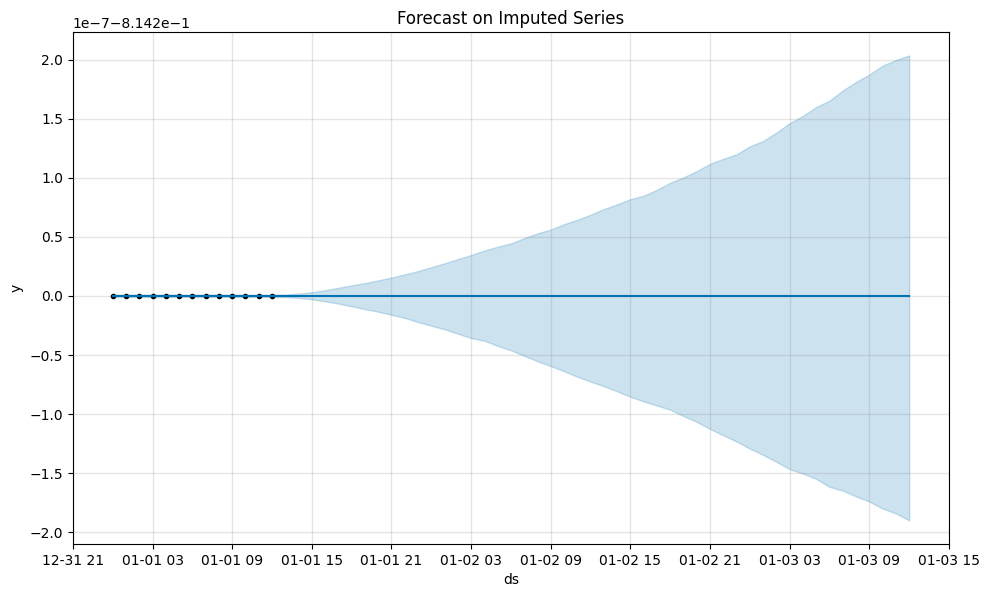

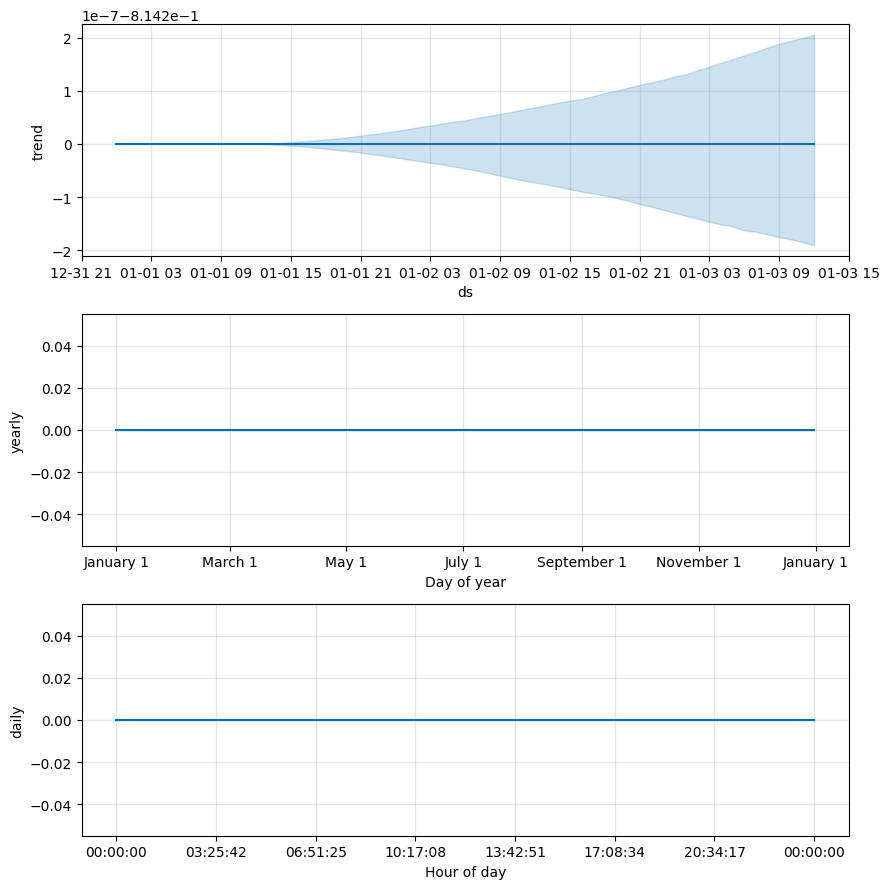

In [100]:
from prophet import Prophet

# Use previously created plot_df which contains imputed results
# Assume we want to build forecast using best method (lowest MAE), e.g., TKCM_Weighted

# Simulate hourly time index (same length as tkcm_imputed)
# In real case, this should come from your normalized_df.index
num_points = len(plot_df)
time_index = pd.date_range(start="2023-01-01", periods=num_points, freq="H")

# Simulate tkcm_imputed from the Method with lowest MAE (e.g., TKCM_Weighted)
# Replace this with your actual `tkcm_imputed` array when running in full context
best_method = plot_df.sort_values("MAE").iloc[0]["Method"]
imputed_values = plot_df.set_index("Method").loc[best_method, "Imputed Value"]

# If only one value, replicate it (for simulation purposes)
imputed_series = [imputed_values] * num_points

# Build Prophet input
df_prophet = pd.DataFrame({
    "ds": time_index,
    "y": imputed_series
}).dropna()

# Fit Prophet model
model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(df_prophet)

# Forecast next 48 hours
future = model.make_future_dataframe(periods=48, freq="H")
forecast = model.predict(future)

# Plot forecast
fig1 = model.plot(forecast)
plt.title("Forecast on Imputed Series")
plt.show()

# Plot components
fig2 = model.plot_components(forecast)
plt.show()
